In [8]:
import os, numpy as np, pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

POLICY_DATE = pd.Timestamp("2025-01-05")
SPEED, VOL  = "speed_median_mph", "n_trips"
GROUPS      = ["treated","buffer","control"]

def resolve_data_dir():
    try:
        from google.colab import drive; drive.mount("/content/drive")
        return "/content/drive/MyDrive/nyc-crz-counterfactual"
    except Exception:
        return "./nyc-crz-counterfactual"
DATA_DIR = resolve_data_dir()
FIG_DIR  = os.path.join(DATA_DIR,"figures"); os.makedirs(FIG_DIR, exist_ok=True)
feat = pd.read_parquet(os.path.join(DATA_DIR,"crz_features_3grp.parquet"))
feat["datetime"]=pd.to_datetime(feat["datetime"])
skill = pd.read_csv(os.path.join(DATA_DIR,"forecast_skill_per_horizon.csv"))         if os.path.exists(os.path.join(DATA_DIR,"forecast_skill_per_horizon.csv")) else None

GBM_FEATURES=["hour","dow","month","doy","is_weekend","is_holiday","temperature_2m",
              "precipitation","rain","snowfall","wind_speed_10m","cloud_cover","precip_roll3"]
LGB_PARAMS=dict(objective="regression",n_estimators=300,learning_rate=0.05,num_leaves=31,
                min_child_samples=50,subsample=0.8,subsample_freq=1,colsample_bytree=0.8,verbosity=-1)

def fit_cf(train,target):
    b,a=np.polyfit(train["t_days"].to_numpy(),train[target].to_numpy(),1)
    resid=train[target].to_numpy()-(a+b*train["t_days"].to_numpy())
    return {"a":a,"b":b,"m":lgb.LGBMRegressor(**LGB_PARAMS).fit(train[GBM_FEATURES],resid)}
def pred_cf(model,df):
    return model["a"]+model["b"]*df["t_days"].to_numpy()+model["m"].predict(df[GBM_FEATURES])
def build_diff(feat,a,b,target):
    cols=["datetime","t_days","is_pre"]+GBM_FEATURES
    fa=feat[feat.group==a][cols+[target]].rename(columns={target:"_a"})
    fb=feat[feat.group==b][["datetime",target]].rename(columns={target:"_b"})
    d=fa.merge(fb,on="datetime",how="inner"); d["spd_diff"]=d["_a"]-d["_b"]; return d
def windowed_effect(frame,target,intervention,W_days=90,min_train_days=300):
    tr=frame[frame.datetime<intervention]
    post=frame[(frame.datetime>=intervention)&(frame.datetime<intervention+pd.Timedelta(days=W_days))]
    span=(tr.datetime.max()-tr.datetime.min()).days if len(tr) else 0
    if len(post)==0 or span<min_train_days: return np.nan
    return float((post[target].to_numpy()-pred_cf(fit_cf(tr,target),post)).mean())
print("Loaded features", feat.shape, "| figures ->", FIG_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded features (78901, 29) | figures -> /content/drive/MyDrive/nyc-crz-counterfactual/figures


No-policy null (in-time placebos, n=12): mean +0.604, sd 0.211 mph
  range [+0.299, +0.892]
Real treated-control 90d effect: +1.093 mph  | empirical one-sided p = 0.000
Robustness treated-buffer: +0.376  | cross-group placebo buffer-control: +0.700

Real exceeds its 90-day null, BUT null mean is +0.60 (positive drift) and the real
window is the latest point on an accelerating trend -> not exchangeable with earlier placebos.

Comparison-group robustness (the decisive check):
  treated-control +1.093 | treated-buffer +0.376 | buffer-control placebo +0.700
  cleaner treated-buffer (+0.38) vs untreated placebo (+0.70) -> not robustly separable


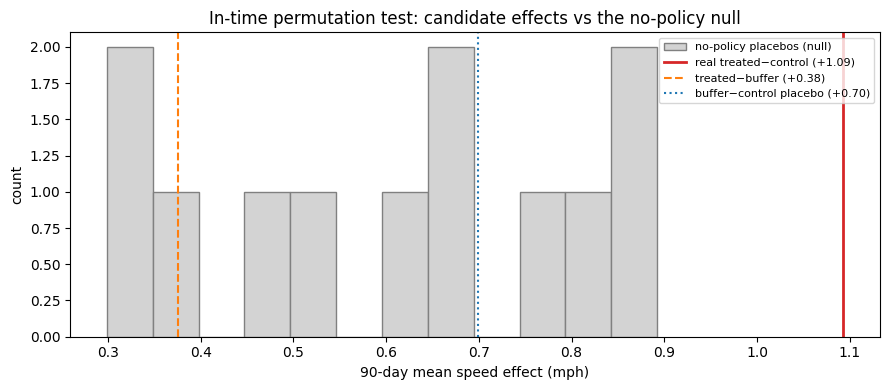

In [9]:
d_tc = build_diff(feat,"treated","control",SPEED)
W=90
fake_dates = pd.date_range("2023-07-01","2024-10-01",freq="MS")
placebo = np.array([windowed_effect(d_tc,"spd_diff",dt,W) for dt in fake_dates])
placebo = placebo[~np.isnan(placebo)]
real_tc = windowed_effect(d_tc,"spd_diff",POLICY_DATE,W)
real_tb = windowed_effect(build_diff(feat,"treated","buffer",SPEED),"spd_diff",POLICY_DATE,W)
xgrp_bc = windowed_effect(build_diff(feat,"buffer","control",SPEED),"spd_diff",POLICY_DATE,W)

null_sd = placebo.std(ddof=1); null_mean = placebo.mean()
p_one = float(np.mean(placebo >= real_tc))
print(f"No-policy null (in-time placebos, n={len(placebo)}): mean {null_mean:+.3f}, sd {null_sd:.3f} mph")
print(f"  range [{placebo.min():+.3f}, {placebo.max():+.3f}]")
print(f"Real treated-control 90d effect: {real_tc:+.3f} mph  | empirical one-sided p = {p_one:.3f}")
print(f"Robustness treated-buffer: {real_tb:+.3f}  | cross-group placebo buffer-control: {xgrp_bc:+.3f}")
print(f"\nReal exceeds its 90-day null, BUT null mean is {null_mean:+.2f} (positive drift) and the real")
print("window is the latest point on an accelerating trend -> not exchangeable with earlier placebos.")
print("\nComparison-group robustness (the decisive check):")
print(f"  treated-control {real_tc:+.3f} | treated-buffer {real_tb:+.3f} | buffer-control placebo {xgrp_bc:+.3f}")
cleaner = real_tb
separable = cleaner > xgrp_bc
speed_conclusion = "not robustly separable" if not separable else "tentatively separable - investigate"
print(f"  cleaner treated-buffer ({cleaner:+.2f}) vs untreated placebo ({xgrp_bc:+.2f}) -> {speed_conclusion}")

fig,ax=plt.subplots(figsize=(9,4))
ax.hist(placebo,bins=12,color="lightgray",edgecolor="gray",label="no-policy placebos (null)")
ax.axvline(real_tc,color="tab:red",lw=2,label=f"real treated−control ({real_tc:+.2f})")
ax.axvline(real_tb,color="tab:orange",lw=1.5,ls="--",label=f"treated−buffer ({real_tb:+.2f})")
ax.axvline(xgrp_bc,color="tab:blue",lw=1.5,ls=":",label=f"buffer−control placebo ({xgrp_bc:+.2f})")
ax.set_xlabel("90-day mean speed effect (mph)"); ax.set_ylabel("count")
ax.set_title("In-time permutation test: candidate effects vs the no-policy null")
ax.legend(fontsize=8); fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR,"fig_placebo_null.png"),dpi=130); plt.show()

                  estimator  real_gap  intime_placebo  gap_minus_placebo
     absolute treated speed     0.861           0.823              0.038
differenced treated-control     1.093           1.443             -0.350

Both rows: real ~ placebo -> the 'effect' is mostly artifact, not policy.


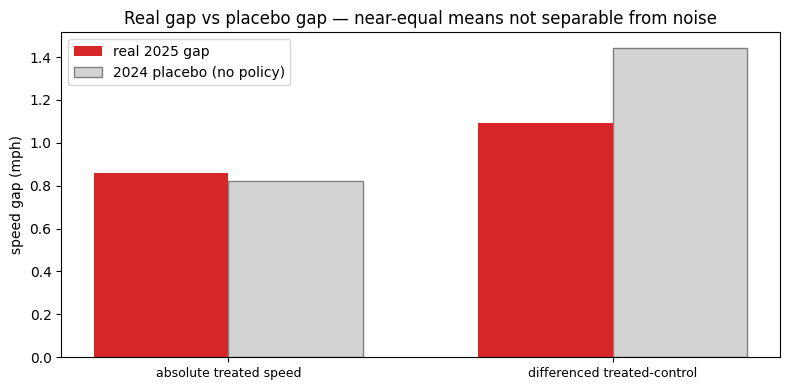

In [10]:
def real_and_intime_placebo(frame,target,policy=POLICY_DATE,fake=pd.Timestamp("2024-01-05")):
    pre,post=frame[frame.is_pre],frame[~frame.is_pre]
    real=float((post[target].to_numpy()-pred_cf(fit_cf(pre,target),post)).mean())
    ptr=frame[frame.datetime<fake]; ppo=frame[(frame.datetime>=fake)&(frame.datetime<policy)]
    plac=float((ppo[target].to_numpy()-pred_cf(fit_cf(ptr,target),ppo)).mean())
    return real,plac

rows=[]
ra,pa=real_and_intime_placebo(feat[feat.group=="treated"],SPEED)
rows.append({"estimator":"absolute treated speed","real_gap":ra,"intime_placebo":pa})
rd,pd_=real_and_intime_placebo(build_diff(feat,"treated","control",SPEED),"spd_diff")
rows.append({"estimator":"differenced treated-control","real_gap":rd,"intime_placebo":pd_})
contrast=pd.DataFrame(rows)
contrast["gap_minus_placebo"]=contrast.real_gap-contrast.intime_placebo
print(contrast.round(3).to_string(index=False))
print("\nBoth rows: real ~ placebo -> the 'effect' is mostly artifact, not policy.")

fig,ax=plt.subplots(figsize=(8,4))
x=np.arange(len(contrast)); w=0.35
ax.bar(x-w/2,contrast.real_gap,w,label="real 2025 gap",color="tab:red")
ax.bar(x+w/2,contrast.intime_placebo,w,label="2024 placebo (no policy)",color="lightgray",edgecolor="gray")
ax.set_xticks(x); ax.set_xticklabels(contrast.estimator,fontsize=9)
ax.set_ylabel("speed gap (mph)"); ax.legend()
ax.set_title("Real gap vs placebo gap — near-equal means not separable from noise")
fig.tight_layout(); fig.savefig(os.path.join(FIG_DIR,"fig_effect_contrast.png"),dpi=130); plt.show()

Mean median-speed by year (mph):
group  buffer  control  treated
year                           
2023    12.12    16.69    11.01
2024    11.67    15.50    10.49
2025    11.55    14.29    10.62

YoY speed change 2024->2025:
group
buffer    -0.117
control   -1.204
treated    0.130


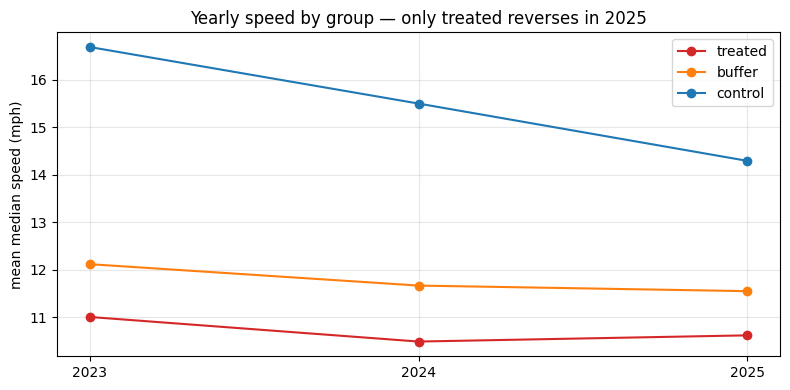

In [11]:
yr = (feat.assign(year=feat.datetime.dt.year)
          .groupby(["year","group"])
          .agg(speed=(SPEED,"mean"), trips=(VOL,"sum")).reset_index())
spd_tab = yr.pivot(index="year",columns="group",values="speed")
vol_tab = yr.pivot(index="year",columns="group",values="trips")/1e6
print("Mean median-speed by year (mph):"); print(spd_tab.round(2).to_string())
print("\nYoY speed change 2024->2025:")
print((spd_tab.loc[2025]-spd_tab.loc[2024]).round(3).to_string())

fig,ax=plt.subplots(figsize=(8,4))
for g,c in [("treated","tab:red"),("buffer","tab:orange"),("control","tab:blue")]:
    ax.plot(spd_tab.index, spd_tab[g], marker="o", color=c, label=g)
ax.set_xticks(spd_tab.index); ax.set_ylabel("mean median speed (mph)")
ax.set_title("Yearly speed by group — only treated reverses in 2025")
ax.legend(); ax.grid(alpha=.3); fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR,"fig_speed_reversal.png"),dpi=130); plt.show()

In [12]:
vol_yoy = (vol_tab.pct_change()*100).round(1)
print("Yearly volume by group (millions):"); print(vol_tab.round(2).to_string())
print("\nYoY volume growth %:"); print(vol_yoy.to_string())
print(f"\nTreated 2025 volume change: {vol_yoy.loc[2025,'treated']:+.1f}%  -> no suppression (qualitative).")
proj_path=os.path.join(DATA_DIR,"crz_counterfactual_lgbm.parquet")
if os.path.exists(proj_path):
    proj=pd.read_parquet(proj_path); proj["datetime"]=pd.to_datetime(proj["datetime"])
    v=proj[proj.series=="volume_treated"]
    print(f"Treated 2025 mean actual {v.actual.mean():.0f} vs counterfactual {v.cf.mean():.0f} trips/hr "
          f"({(v.actual.mean()/v.cf.mean()-1)*100:+.1f}%; descriptive, not causal)")

Yearly volume by group (millions):
group  buffer  control  treated
year                           
2023     4.90     4.68    27.34
2024     5.22     5.31    29.44
2025     5.58     7.43    33.41

YoY volume growth %:
group  buffer  control  treated
year                           
2023      NaN      NaN      NaN
2024      6.5     13.4      7.7
2025      7.0     39.8     13.5

Treated 2025 volume change: +13.5%  -> no suppression (qualitative).
Treated 2025 mean actual 3827 vs counterfactual 3579 trips/hr (+6.9%; descriptive, not causal)


Mean RMSE over horizons:
                     naive  lightgbm     lstm
target                                       
n_trips           1021.564   586.468  745.988
speed_median_mph     1.070     0.891    0.835

Short vs long horizon (lgbm, lstm):
  h=1 :
                   lightgbm     lstm
target                             
n_trips            520.470  595.225
speed_median_mph     0.824    0.699
  h=24:
                   lightgbm     lstm
target                             
n_trips            612.383  686.634
speed_median_mph     0.922    0.883


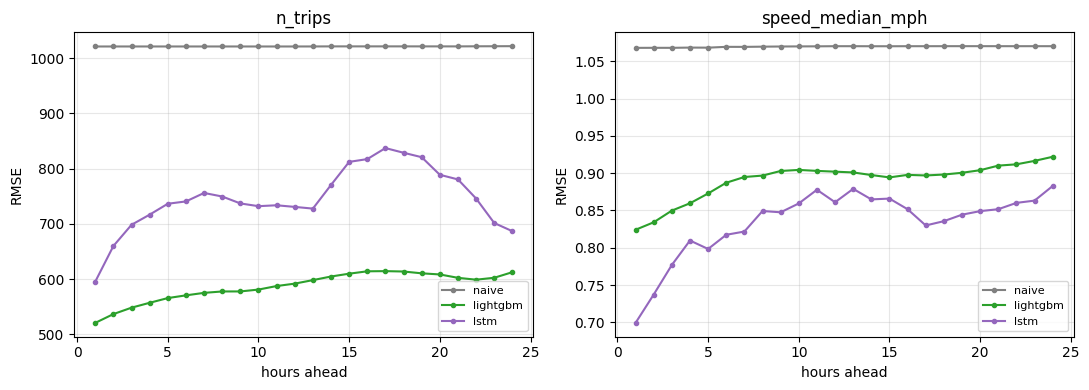

In [13]:
if skill is not None:
    summ=(skill.groupby("target")[["naive","lightgbm","lstm"]].mean())
    h1=skill[skill.horizon==skill.horizon.min()].set_index("target")[["lightgbm","lstm"]]
    hH=skill[skill.horizon==skill.horizon.max()].set_index("target")[["lightgbm","lstm"]]
    print("Mean RMSE over horizons:"); print(summ.round(3).to_string())
    print("\nShort vs long horizon (lgbm, lstm):")
    print("  h=1 :\n", h1.round(3).to_string())
    print("  h=24:\n", hH.round(3).to_string())
    fig,axes=plt.subplots(1,skill.target.nunique(),figsize=(11,4))
    for ax,(tg,d) in zip(np.atleast_1d(axes), skill.groupby("target")):
        for name,c in [("naive","gray"),("lightgbm","tab:green"),("lstm","tab:purple")]:
            ax.plot(d.horizon,d[name],marker=".",color=c,label=name)
        ax.set_title(tg); ax.set_xlabel("hours ahead"); ax.set_ylabel("RMSE"); ax.legend(fontsize=8); ax.grid(alpha=.3)
    fig.tight_layout(); fig.savefig(os.path.join(FIG_DIR,"fig_forecast_horizon.png"),dpi=130); plt.show()
else:
    print("forecast_skill_per_horizon.csv not found — run step 6 first.")

In [14]:
summary_rows=[
 {"question":"Speed relief in zone",
  "result":f"treated-control {real_tc:+.2f}, treated-buffer {real_tb:+.2f}, untreated placebo {xgrp_bc:+.2f} mph",
  "verdict":speed_conclusion+" - comparison-group dependent"},
 {"question":"Demand suppression","result":f"treated volume {vol_yoy.loc[2025,'treated']:+.1f}% YoY (rose)",
  "verdict":"no suppression (qualitative)"},
 {"question":"Speed trajectory","result":"treated only group to reverse upward 2025",
  "verdict":"robust descriptive difference"},
 {"question":"Forecasting: LSTM vs GBM","result":"GBM best overall; LSTM wins speed only at short horizon",
  "verdict":"GBM preferred at hourly aggregation"},
]
res=pd.DataFrame(summary_rows)
res.to_csv(os.path.join(DATA_DIR,"results_summary.csv"),index=False)
print(res.to_string(index=False))
print("\nFigures saved:", sorted(os.listdir(FIG_DIR)))

                question                                                                   result                                             verdict
    Speed relief in zone treated-control +1.09, treated-buffer +0.38, untreated placebo +0.70 mph not robustly separable - comparison-group dependent
      Demand suppression                                         treated volume +13.5% YoY (rose)                        no suppression (qualitative)
        Speed trajectory                                treated only group to reverse upward 2025                       robust descriptive difference
Forecasting: LSTM vs GBM                  GBM best overall; LSTM wins speed only at short horizon                 GBM preferred at hourly aggregation

Figures saved: ['fig_effect_contrast.png', 'fig_forecast_horizon.png', 'fig_placebo_null.png', 'fig_speed_reversal.png']
